# Variational Autoencoder

## Data preparation

In [1]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2
from tqdm.auto import tqdm

torch.manual_seed(123)

batch_size = 512
learning_rate = 5*1e-3
num_epochs = 50
latent_dim = 2
hidden_dim = [512, 256]

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Lambda(lambda x: x.view(-1)),
])

train_data = datasets.FashionMNIST('FashionMNIST_data/', download=False, train=True, transform=transform)
test_data = datasets.FashionMNIST('FashionMNIST_data/', download=False, train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

for X, _ in train_loader:
    input_dim = X.shape[1]
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    break

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

c:\Users\caslu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape of X [N, C, H, W]: torch.Size([512, 784])
Using device: cuda


## Autoencoder definition

In [36]:
@dataclass
class AEOutput:
    """
    Dataclass for AE output.
    """
    z_proj: torch.Tensor    
    x_recon: torch.Tensor    
    loss: torch.Tensor

class AE(nn.Module):
    """
    Autoencoder (VAE) class.
    
    Args:
        input_dim (int): Dimensionality of the input data.
        hidden_dim (int): Dimensionality of the hidden layers.
        latent_dim (int): Dimensionality of the latent space.
    """
    
    def __init__(self, input_dim, hidden_dim, latent_dim, num_classes = 0, cond = False):
        super(AE, self).__init__()
       
        self.num_classes = num_classes
        self.cond = cond
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        enc_input_dim = input_dim + num_classes if cond else input_dim
        dec_input_dim = latent_dim + num_classes if cond else latent_dim
        
        encoder_layers_list = []
        if type(hidden_dim) != list:
            encoder_layers_list.append(nn.Linear(enc_input_dim, hidden_dim))
            encoder_layers_list.append(nn.LeakyReLU())
            encoder_layers_list.append(nn.Linear(hidden_dim, 2 * latent_dim))
        else:
            self.hidden_dim = hidden_dim.copy()
            encoder_layers_list.append(nn.Linear(enc_input_dim, hidden_dim[0]))
            encoder_layers_list.append(nn.LeakyReLU())
            for i in range(len(hidden_dim[1:])):
                encoder_layers_list.append(nn.Linear(hidden_dim[i], hidden_dim[i+1]))
                encoder_layers_list.append(nn.LeakyReLU())
            encoder_layers_list.append(nn.Linear(hidden_dim[-1], latent_dim))
        
        self.encoder = nn.Sequential(*encoder_layers_list)

        decoder_layers_list = []
        if type(hidden_dim) != list:
            decoder_layers_list.append(nn.Linear(dec_input_dim, hidden_dim))
            decoder_layers_list.append(nn.LeakyReLU())
            decoder_layers_list.append(nn.Linear(hidden_dim, input_dim))
            decoder_layers_list.append(nn.Sigmoid())
        else:
            hidden_dim_decoder = hidden_dim[::-1]
            decoder_layers_list.append(nn.Linear(dec_input_dim, hidden_dim_decoder[0]))
            decoder_layers_list.append(nn.LeakyReLU())
            for i in range(len(hidden_dim_decoder[1:])):
                decoder_layers_list.append(nn.Linear(hidden_dim_decoder[i], hidden_dim_decoder[i+1]))
                decoder_layers_list.append(nn.LeakyReLU())
            decoder_layers_list.append(nn.Linear(hidden_dim_decoder[-1], input_dim))
            decoder_layers_list.append(nn.Sigmoid())

        self.decoder = nn.Sequential(*decoder_layers_list)

        print(f"Encoder: {encoder_layers_list}")
        print(f"Decoder: {decoder_layers_list}")

    def encode(self, x, y = None):    
        if self.cond:
            y = y.to(device)
            x = torch.cat([x,y], dim= 1)    
        return self.encoder(x)
        
    def decode(self, z, y = None):
        if self.cond:
            y = y.to(device)
            z = torch.cat([z,y], dim= 1)
        return self.decoder(z)
    
    def forward(self, x, y = None,compute_loss: bool = True):
        z_proj = self.encode(x, y)
        recon_x = self.decode(z_proj, y)
        
        if not compute_loss:
            return AEOutput(
                z_proj=z_proj,
                x_recon=recon_x,
                loss=None,
            )
        
        loss = F.binary_cross_entropy(recon_x, x, reduction='none').sum(-1).mean()
        
        return AEOutput(
                z_proj=z_proj,
                x_recon=recon_x,
                loss=loss,
            )

## Variational Autoencoder definition

In [28]:
@dataclass
class VAEOutput:
    """
    Dataclass for VAE output.
    
    Attributes:
        z_dist (torch.distributions.Distribution): The distribution of the latent variable z.
        z_sample (torch.Tensor): The sampled value of the latent variable z.
        x_recon (torch.Tensor): The reconstructed output from the VAE.
        loss (torch.Tensor): The overall loss of the VAE.
        loss_recon (torch.Tensor): The reconstruction loss component of the VAE loss.
        loss_kl (torch.Tensor): The KL divergence component of the VAE loss.
    """
    z_dist: torch.distributions.Distribution
    z_sample: torch.Tensor
    x_recon: torch.Tensor
    
    loss: torch.Tensor
    loss_recon: torch.Tensor
    loss_kl: torch.Tensor

class VAE(nn.Module):
    """
    Variational Autoencoder (VAE) class.
    
    Args:
        input_dim (int): Dimensionality of the input data.
        hidden_dim (int): Dimensionality of the hidden layers.
        latent_dim (int): Dimensionality of the latent space.
    """
    
    def __init__(self, input_dim, hidden_dim, latent_dim, num_classes = 0 , cond = False):
        super(VAE, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.cond = cond
        enc_input_dim = input_dim + num_classes if cond else input_dim
        dec_input_dim = latent_dim + num_classes if cond else latent_dim

        encoder_layers_list = []
        if type(hidden_dim) != list:
            encoder_layers_list.append(nn.Linear(enc_input_dim, hidden_dim))
            encoder_layers_list.append(nn.LeakyReLU())
            encoder_layers_list.append(nn.Linear(hidden_dim, 2 * latent_dim))
        else:
            self.hidden_dim = hidden_dim.copy()
            encoder_layers_list.append(nn.Linear(enc_input_dim, hidden_dim[0]))
            encoder_layers_list.append(nn.LeakyReLU())
            for i in range(len(hidden_dim[1:])):
                encoder_layers_list.append(nn.Linear(hidden_dim[i], hidden_dim[i+1]))
                encoder_layers_list.append(nn.LeakyReLU())
            encoder_layers_list.append(nn.Linear(hidden_dim[-1], 2 * latent_dim))
        
        self.encoder = nn.Sequential(*encoder_layers_list)
        self.softplus = nn.Softplus()

        decoder_layers_list = []
        if type(hidden_dim) != list:
            decoder_layers_list.append(nn.Linear(dec_input_dim, hidden_dim))
            decoder_layers_list.append(nn.LeakyReLU())
            decoder_layers_list.append(nn.Linear(hidden_dim, input_dim))
            decoder_layers_list.append(nn.Sigmoid())
        else:
            hidden_dim_decoder = hidden_dim[::-1]
            decoder_layers_list.append(nn.Linear(dec_input_dim, hidden_dim_decoder[0]))
            decoder_layers_list.append(nn.LeakyReLU())
            for i in range(len(hidden_dim_decoder[1:])):
                decoder_layers_list.append(nn.Linear(hidden_dim_decoder[i], hidden_dim_decoder[i+1]))
                decoder_layers_list.append(nn.LeakyReLU())
            decoder_layers_list.append(nn.Linear(hidden_dim_decoder[-1], input_dim))
            decoder_layers_list.append(nn.Sigmoid())

        self.decoder = nn.Sequential(*decoder_layers_list)

        print(f"Encoder: {encoder_layers_list}")
        print(f"Decoder: {decoder_layers_list}")

    def encode(self, x: torch.tensor, y = None,  eps: float = 1e-8):
        """
        Encodes the input data into the latent space.
        
        Args:
            x (torch.Tensor): Input data.
            eps (float): Small value to avoid numerical instability.
        
        Returns:
            torch.distributions.MultivariateNormal: Normal distribution of the encoded data.
        """

        if self.cond:
            y = y.to(device)
            x = torch.cat([x,y], dim = 1)
        h = self.encoder(x)
        
        mu, logvar = torch.chunk(h, 2, dim= -1)

        var = self.softplus(logvar) + eps

        cov = torch.diag_embed(var)
        
        return torch.distributions.MultivariateNormal(loc = mu, covariance_matrix= cov)


    def reparameterize(self, dist):
        """
        Reparameterizes the encoded data to sample from the latent space.
        
        Args:
            dist (torch.distributions.MultivariateNormal): Normal distribution of the encoded data.
        Returns:
            torch.Tensor: Sampled data from the latent space.
        """
        return dist.rsample()
    
    def decode(self, z, y = None):
        """
        Decodes the data from the latent space to the original input space.
        
        Args:
            z (torch.Tensor): Data in the latent space.
        
        Returns:
            torch.Tensor: Reconstructed data in the original input space.
        """
        if self.cond:
            y = y.to(device)
            z = torch.cat([z,y], dim =1)
        return self.decoder(z)
    
    def forward(self, x, y = None, compute_loss: bool = True):
        """
        Performs a forward pass of the VAE.
        
        Args:
            x (torch.Tensor): Input data.
            compute_loss (bool): Whether to compute the loss or not.
        
        Returns:
            VAEOutput: VAE output dataclass.
        """
        
        dist = self.encode(x, y)
        z = self.reparameterize(dist)
        recon_x = self.decode(z, y)
        
        if not compute_loss:
            return VAEOutput(
                z_dist=dist,
                z_sample=z,
                x_recon=recon_x,
                loss=None,
                loss_recon=None,
                loss_kl=None,
            )
        
        # compute loss terms 
        loss_recon = F.binary_cross_entropy(recon_x, x, reduction='none').sum(-1).mean()
        std_normal = torch.distributions.MultivariateNormal(
            torch.zeros_like(z, device=z.device),
            scale_tril=torch.eye(z.shape[-1], device=z.device).unsqueeze(0).expand(z.shape[0], -1, -1),
        )
        loss_kl = torch.distributions.kl.kl_divergence(dist, std_normal).mean()
                
        loss = loss_recon + loss_kl
        
        return VAEOutput(
            z_dist=dist,
            z_sample=z,
            x_recon=recon_x,
            loss=loss,
            loss_recon=loss_recon,
            loss_kl=loss_kl,
        )

## Train and Test functions

In [4]:
def train(model, dataloader, optimizer, prev_updates):
    """
    Trains the model on the given data.
    
    Args:
        model (nn.Module): The model to train.
        dataloader (torch.utils.data.DataLoader): The data loader.
        loss_fn: The loss function.
        optimizer: The optimizer.
    """
    model.train()  # Set the model to training mode
    
    loss_history = []
    for batch_idx, (data, y) in enumerate(tqdm(dataloader, desc='Training')):
        n_upd = prev_updates + batch_idx
        
        data = data.to(device)
        data = data.view(data.size(0), -1)

        optimizer.zero_grad()  # Zero the gradients
        
        if model.cond:
            y = y.to(device)
            y_oneHot = F.one_hot(y, num_classes= model.num_classes).float()
            output = model(data, y_oneHot)  # Forward pass
        else:
            output = model(data)
        
        loss = output.loss
        loss.backward()

        optimizer.step()  # Update the model parameters
        
        loss_history.append(loss.item())

    print(f'Step {n_upd:,} (N samples: {n_upd*batch_size:,}), Train set loss: {np.mean(loss_history):.4f}') 

    return prev_updates + len(dataloader), loss_history

def test(model, dataloader):
    """
    Tests the model on the given data.
    
    Args:
        model (nn.Module): The model to test.
        dataloader (torch.utils.data.DataLoader): The data loader.
    """
    model.eval()  # Set the model to evaluation mode
    test_loss = 0
    
    with torch.no_grad():
        for data, y in tqdm(dataloader, desc='Testing'):
            data = data.to(device)
            data = data.view(data.size(0), -1)  # Flatten the data
            
            if model.cond:
                y = y.to(device)
                y_oneHot = F.one_hot(y, num_classes= model.num_classes).float()
                output = model(data, y_oneHot, compute_loss = True)
            
            else:
                output = model(data, compute_loss=True)  # Forward pass
            
            test_loss += output.loss.item()
            
    test_loss /= len(dataloader)
    print(f'====> Test set loss: {test_loss:.4f}')

    return test_loss

## Train the Autoencoder

In [5]:
print("Training Autoencoder...")
model_AE = AE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
print(model_AE)
optimizer = torch.optim.AdamW(model_AE.parameters(), lr=learning_rate)

train_loss_history_AE = []
test_loss_history_AE = []
prev_updates = 0
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    prev_updates, train_loss = train(model_AE, train_loader, optimizer, prev_updates)
    test_loss = test(model_AE, test_loader)
    train_loss_history_AE.append(np.mean(train_loss))
    test_loss_history_AE.append(test_loss)

Training Autoencoder...
Encoder: [Linear(in_features=784, out_features=512, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=512, out_features=256, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=256, out_features=2, bias=True)]
Decoder: [Linear(in_features=2, out_features=256, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=256, out_features=512, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=512, out_features=784, bias=True), Sigmoid()]
AE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): Leak

Training: 100%|██████████| 118/118 [00:34<00:00,  3.39it/s]


Step 117 (N samples: 59,904), Train set loss: 295.6140


Testing: 100%|██████████| 20/20 [00:05<00:00,  3.69it/s]


====> Test set loss: 266.0316
Epoch 2/50


...

====> Test set loss: 246.9188
Epoch 50/50


Training: 100%|██████████| 118/118 [00:09<00:00, 12.48it/s]


Step 5,899 (N samples: 3,020,288), Train set loss: 244.6564


Testing: 100%|██████████| 20/20 [00:01<00:00, 19.11it/s]

====> Test set loss: 246.9816


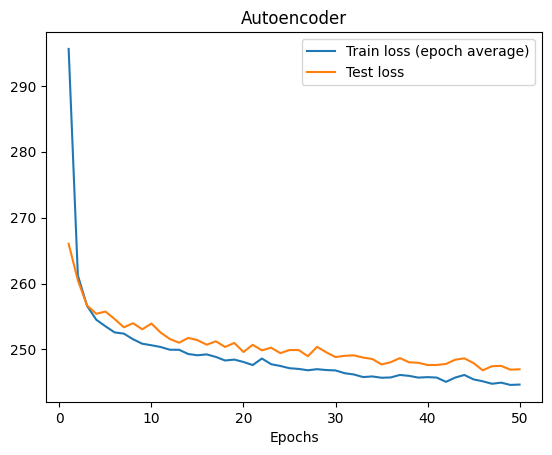

In [6]:
plt.plot(range(1,len(train_loss_history_AE)+1), train_loss_history_AE, label="Train loss (epoch average)")
plt.plot(range(1,len(train_loss_history_AE)+1), test_loss_history_AE, label="Test loss")
plt.legend()
plt.xlabel("Epochs")
plt.title("Autoencoder")
plt.show()

## Train the Variational Autoencoder

In [7]:
print("Training Variational Autoencoder...")
model_VAE = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
print(model_VAE)
optimizer = torch.optim.AdamW(model_VAE.parameters(), lr=learning_rate)

train_loss_history_VAE = []
test_loss_history_VAE = []
prev_updates = 0
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    prev_updates, train_loss = train(model_VAE, train_loader, optimizer, prev_updates)
    test_loss = test(model_VAE, test_loader)
    train_loss_history_VAE.append(np.mean(train_loss))
    test_loss_history_VAE.append(test_loss)

Training Variational Autoencoder...
Encoder: [Linear(in_features=784, out_features=512, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=512, out_features=256, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=256, out_features=4, bias=True)]
Decoder: [Linear(in_features=2, out_features=256, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=256, out_features=512, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=512, out_features=784, bias=True), Sigmoid()]
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Line

Training: 100%|██████████| 118/118 [00:09<00:00, 12.52it/s]


Step 117 (N samples: 59,904), Train set loss: 301.7946


Testing: 100%|██████████| 20/20 [00:01<00:00, 17.22it/s]


====> Test set loss: 274.4579
Epoch 2/50


...

====> Test set loss: 257.0025
Epoch 50/50


Training: 100%|██████████| 118/118 [00:11<00:00, 10.50it/s]


Step 5,899 (N samples: 3,020,288), Train set loss: 254.0382


Testing: 100%|██████████| 20/20 [00:01<00:00, 16.03it/s]

====> Test set loss: 256.2893


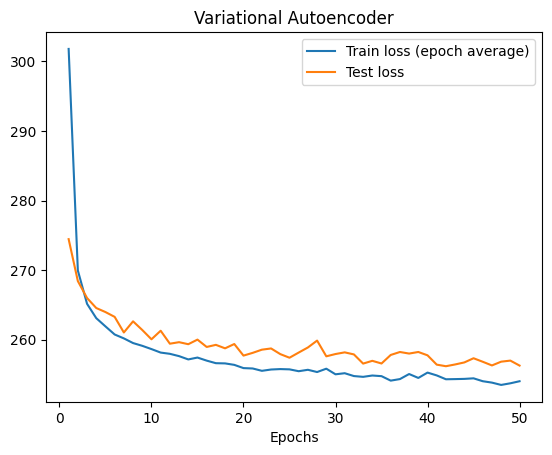

In [8]:
plt.plot(range(1,len(train_loss_history_VAE)+1), train_loss_history_VAE, label="Train loss (epoch average)", )
plt.plot(range(1,len(train_loss_history_VAE)+1), test_loss_history_VAE, label="Test loss")
plt.legend()
plt.xlabel("Epochs")
plt.title("Variational Autoencoder")
plt.show()

# Questão 1

## Plot functions

In [ ]:
def plot_latent_space(model):
    model.eval()
    z_all = []
    y_all = []
    with torch.no_grad():
        for data, target in tqdm(train_loader, desc='Encoding'):

            data = data.to(device)
            data = data.view(data.size(0), -1)

            if model.cond:
                y = target.to(device)
                y_oneHot = F.one_hot(y, model.num_classes).float().to(device)
            else:
                y_oneHot = None

            encoded_data = model.encode(data, y_oneHot)
            
            if isinstance(model, VAE):
                z = model.reparameterize(encoded_data)
                
            else:
                z = encoded_data


            z_all.append(z.cpu())
            y_all.append(target.cpu())

    z_all = torch.cat(z_all, dim=0).numpy()
    y_all = torch.cat(y_all, dim=0).numpy()
    
    plt.figure(figsize=(10, 10))
    plt.scatter(z_all[:, 0], z_all[:, 1], c=y_all, cmap='tab10')
    plt.xlim(-6,6)
    plt.ylim(-6,6)
    plt.colorbar()
    plt.title(f'Latent projection')
    plt.show()

def plot_random_samples(model):

    multivar_normal = torch.distributions.MultivariateNormal(loc = torch.zeros(2, device= device), covariance_matrix= torch.eye(2, device= device))
    samples = []
    
    for _ in range(100):
        s = multivar_normal.sample()
        ger = model.decode(s)
        samples.append(ger.cpu())
        
    fig, ax = plt.subplots(10, 10, figsize=(10, 10))
    for i in range(10):
        for j in range(10):
            ax[i, j].imshow(samples[i*10+j].view(28, 28).cpu().detach().numpy(), cmap='gray')
            ax[i, j].axis('off')
    plt.show()

## Show plots

Autoencoder:


Encoding: 100%|██████████| 118/118 [00:08<00:00, 14.07it/s]


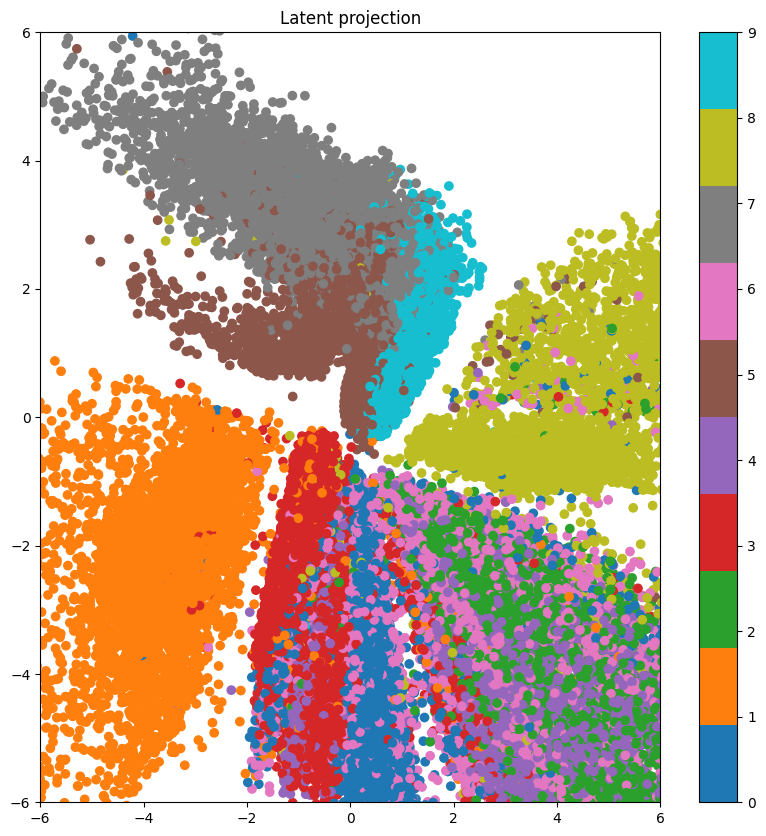

Variational Autoencoder:


Encoding: 100%|██████████| 118/118 [00:07<00:00, 15.99it/s]


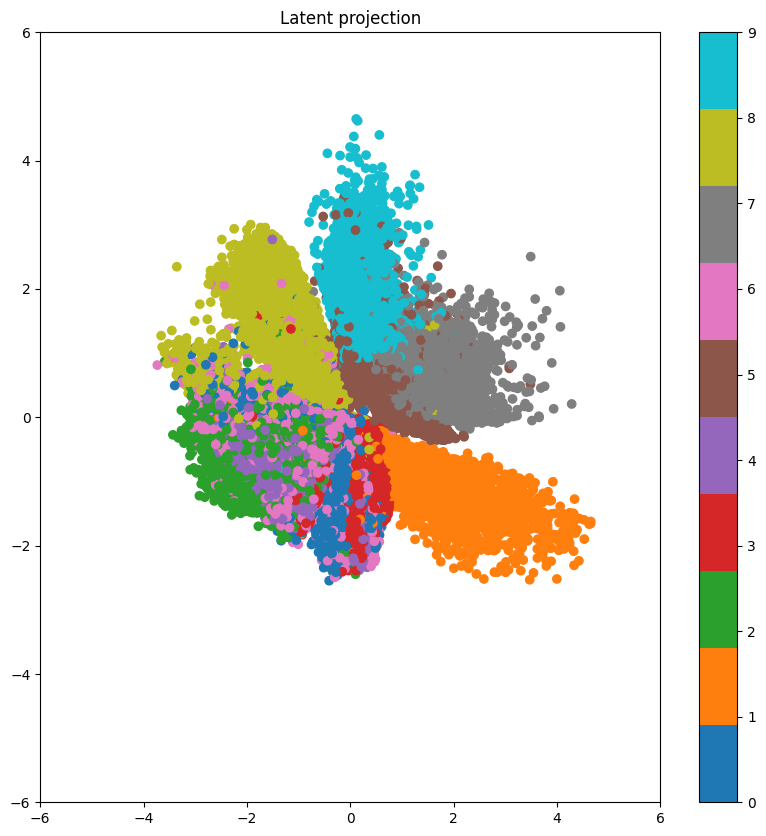

In [16]:
print("Autoencoder:")
plot_latent_space(model_AE)
print("Variational Autoencoder:")
plot_latent_space(model_VAE)

A principal diferença entre as projeções latentes está na concentração do VAE no "centro", enquanto as projeções do autoencoder se espalha, fugindo até mesmo dos limites da figura. A explicação possível é que a priori aplicada no modelo esteja causando esse comportamento.

Autoencoder:


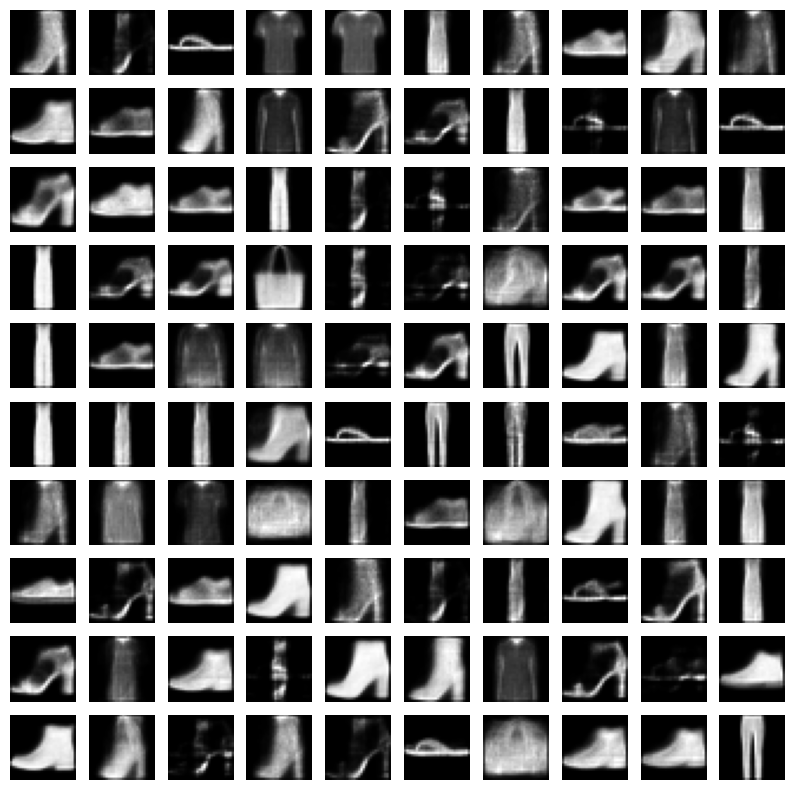

Variational Autoencoder:


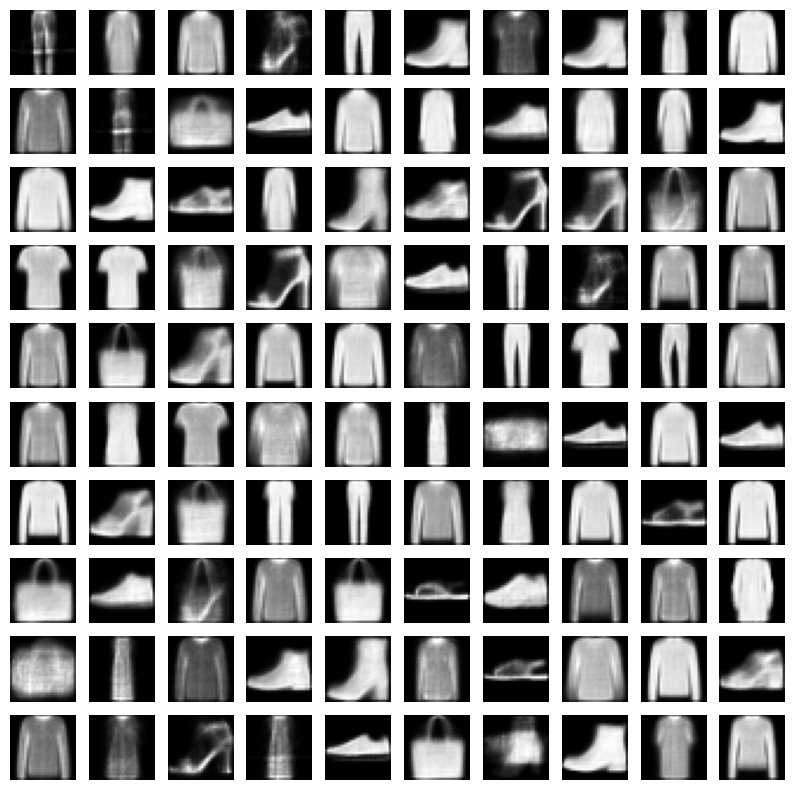

In [21]:
print("Autoencoder:")
plot_random_samples(model_AE)
print("Variational Autoencoder:")
plot_random_samples(model_VAE)

As imagens geradas pelo VAE são mais nítidas e apresentam maior diversidade de criação quando comparadas às geradas pelo autoencoder.

# Questão 2

In [43]:
def plot_conditional_samples(model):
    model.eval()

    num_classes = model.num_classes
    samples = []
    multivar_normal = torch.distributions.MultivariateNormal(loc = torch.zeros(2, device= device), covariance_matrix= torch.eye(2, device= device))

    with torch.no_grad():
        for c in range(num_classes):
            y = torch.full((10,), c, device= device)
            y_oneHot = F.one_hot(y, num_classes).float().to(device)

            z = multivar_normal.sample((10,))
            ger = model.decode(z, y_oneHot)
            
            samples.append(ger.cpu())

    fig, ax = plt.subplots(num_classes, 10, figsize=(10, 10))

    for i in range(num_classes):      
        for j in range(10):           
            ax[i, j].imshow(
                samples[i][j].view(28, 28).numpy(),
                cmap='gray'
            )
            ax[i, j].axis('off')
            if j == 0:
                ax[i, j].set_ylabel(str(i), fontsize=12)

    plt.show()

In [23]:
num_classes = len(train_data.classes)
num_classes

10

### Treinar Autoencoder

In [27]:
print("Training Autoencoder...")
model_AE_cond = AE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim, num_classes= num_classes, cond= True).to(device)
print(model_AE_cond)
optimizer = torch.optim.AdamW(model_AE_cond.parameters(), lr=learning_rate)

train_loss_history_AE = []
test_loss_history_AE = []
prev_updates = 0
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    prev_updates, train_loss = train(model_AE_cond, train_loader, optimizer, prev_updates)
    test_loss = test(model_AE_cond, test_loader)
    train_loss_history_AE.append(np.mean(train_loss))
    test_loss_history_AE.append(test_loss)

Training Autoencoder...
Encoder: [Linear(in_features=794, out_features=512, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=512, out_features=256, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=256, out_features=2, bias=True)]
Decoder: [Linear(in_features=12, out_features=256, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=256, out_features=512, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=512, out_features=784, bias=True), Sigmoid()]
AE(
  (encoder): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): Le

Training:   0%|          | 0/118 [00:00<?, ?it/s]

Training: 100%|██████████| 118/118 [00:09<00:00, 12.00it/s]


Step 117 (N samples: 59,904), Train set loss: 300.1329


Testing: 100%|██████████| 20/20 [00:01<00:00, 18.39it/s]


...

====> Test set loss: 244.1314
Epoch 50/50


Training: 100%|██████████| 118/118 [00:10<00:00, 11.03it/s]


Step 5,899 (N samples: 3,020,288), Train set loss: 241.2115


Testing: 100%|██████████| 20/20 [00:01<00:00, 18.28it/s]

====> Test set loss: 243.5980


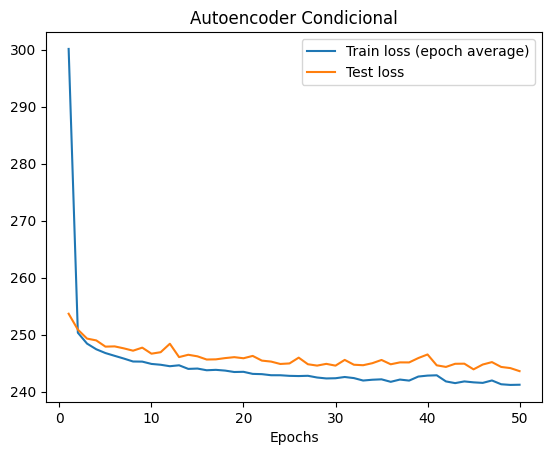

In [29]:
plt.plot(range(1,len(train_loss_history_AE)+1), train_loss_history_AE, label="Train loss (epoch average)")
plt.plot(range(1,len(train_loss_history_AE)+1), test_loss_history_AE, label="Test loss")
plt.legend()
plt.xlabel("Epochs")
plt.title("Autoencoder Condicional")
plt.show()

### Treinar VAE

In [30]:
print("Training Variational Autoencoder...")
model_VAE_cond = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim, num_classes= num_classes, cond= True).to(device)
print(model_VAE_cond)
optimizer = torch.optim.AdamW(model_VAE_cond.parameters(), lr=learning_rate)

train_loss_history_VAE = []
test_loss_history_VAE = []
prev_updates = 0
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    prev_updates, train_loss = train(model_VAE_cond, train_loader, optimizer, prev_updates)
    test_loss = test(model_VAE_cond, test_loader)
    train_loss_history_VAE.append(np.mean(train_loss))
    test_loss_history_VAE.append(test_loss)

Training Variational Autoencoder...
Encoder: [Linear(in_features=794, out_features=512, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=512, out_features=256, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=256, out_features=4, bias=True)]
Decoder: [Linear(in_features=12, out_features=256, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=256, out_features=512, bias=True), LeakyReLU(negative_slope=0.01), Linear(in_features=512, out_features=784, bias=True), Sigmoid()]
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Li

Training: 100%|██████████| 118/118 [00:11<00:00, 10.20it/s]


Step 117 (N samples: 59,904), Train set loss: 297.6111


Testing: 100%|██████████| 20/20 [00:01<00:00, 15.89it/s]


====> Test set loss: 261.2894
Epoch 2/50


...

====> Test set loss: 250.9776
Epoch 50/50


Training: 100%|██████████| 118/118 [00:10<00:00, 10.84it/s]


Step 5,899 (N samples: 3,020,288), Train set loss: 247.3649


Testing: 100%|██████████| 20/20 [00:01<00:00, 14.08it/s]

====> Test set loss: 250.5910


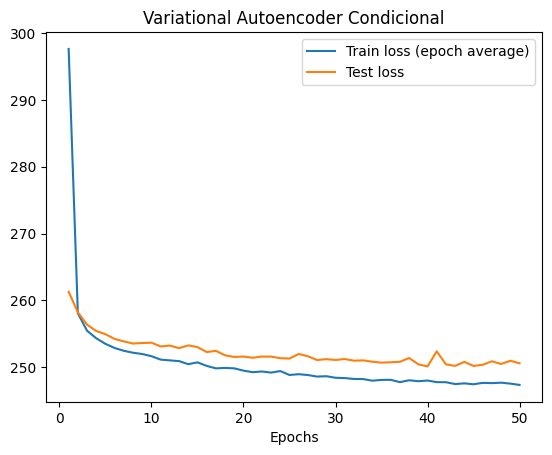

In [31]:
plt.plot(range(1,len(train_loss_history_VAE)+1), train_loss_history_VAE, label="Train loss (epoch average)", )
plt.plot(range(1,len(train_loss_history_VAE)+1), test_loss_history_VAE, label="Test loss")
plt.legend()
plt.xlabel("Epochs")
plt.title("Variational Autoencoder Condicional")
plt.show()

### Plots

Autoencoder:


Encoding: 100%|██████████| 118/118 [00:06<00:00, 17.24it/s]


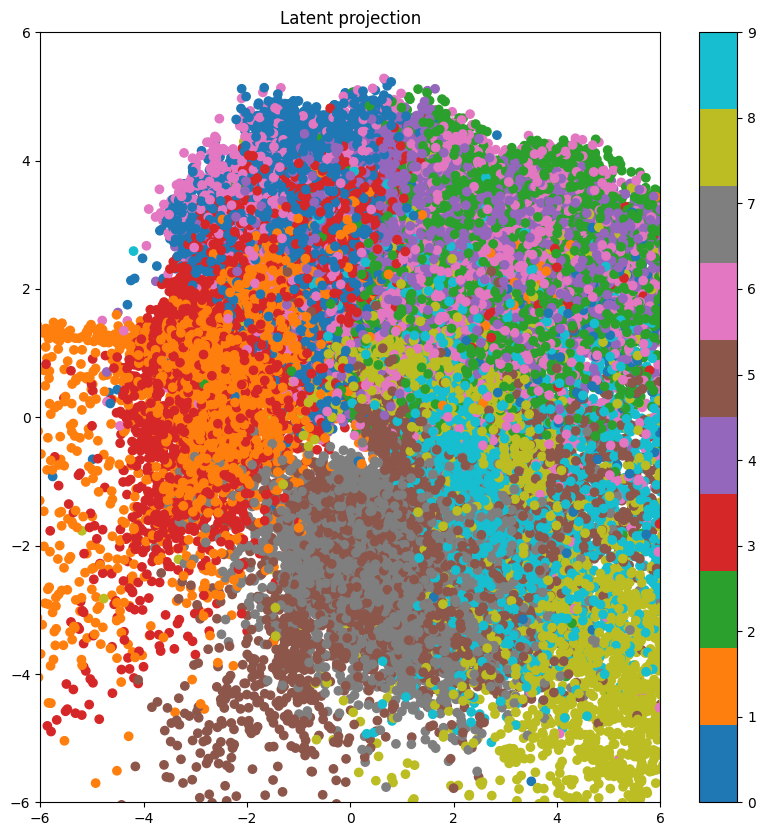

Variational Autoencoder:


Encoding: 100%|██████████| 118/118 [00:08<00:00, 13.72it/s]


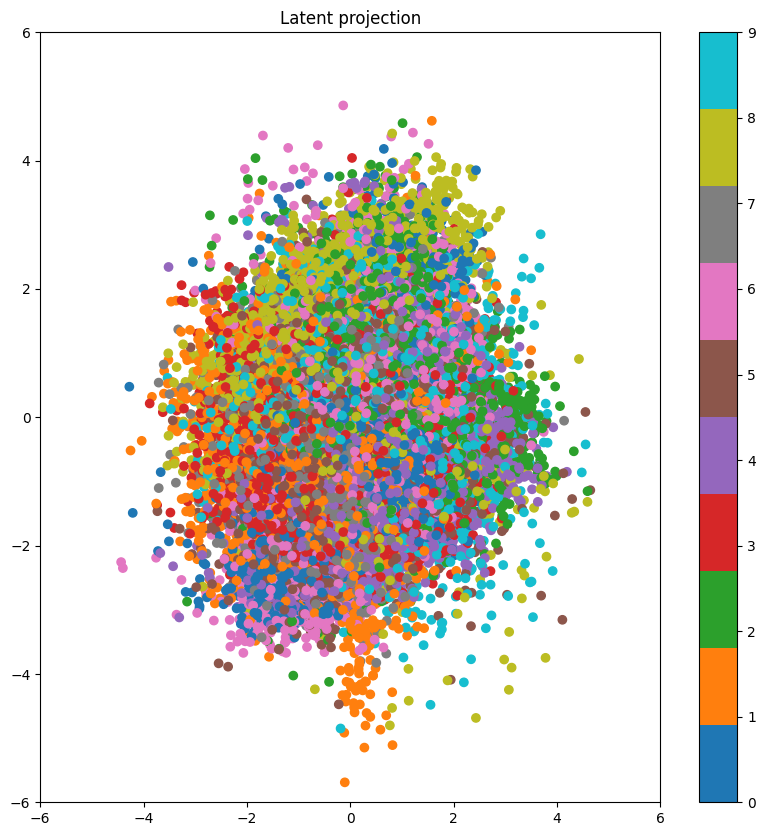

In [46]:
print("Autoencoder:")
plot_latent_space(model_AE_cond)
print("Variational Autoencoder:")
plot_latent_space(model_VAE_cond)

Aqui as classes parecem ter se misturado bastante, o modelo não precisa aprender as classes latentes aos dados, já que elas já são dadas, talvez por isso, no espaço projetado elas não fiquem tão separadas quanto nas primeiras versões.

Autoencoder:


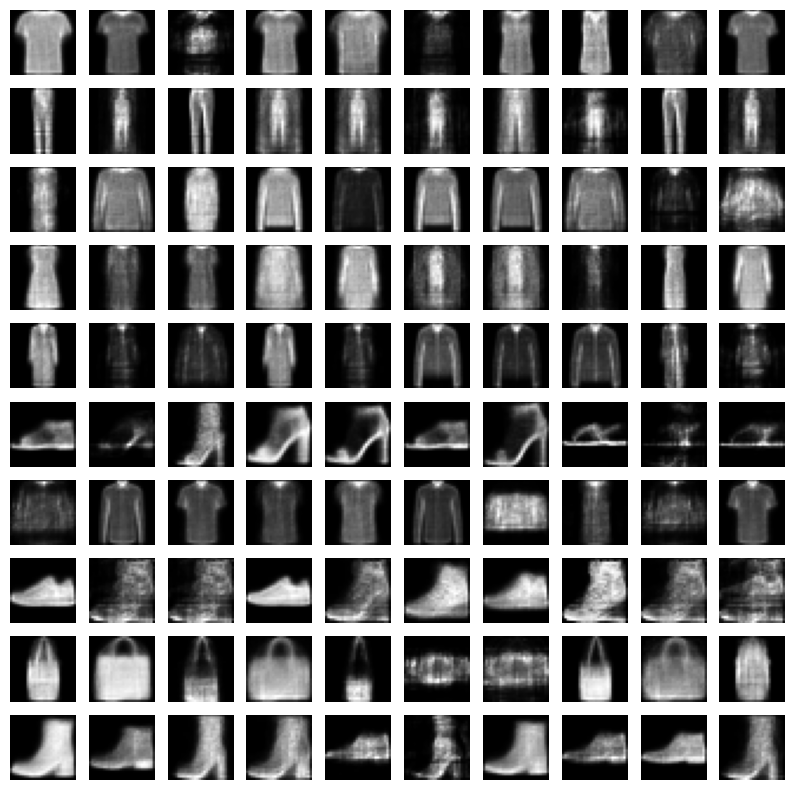

Variational Autoencoder:


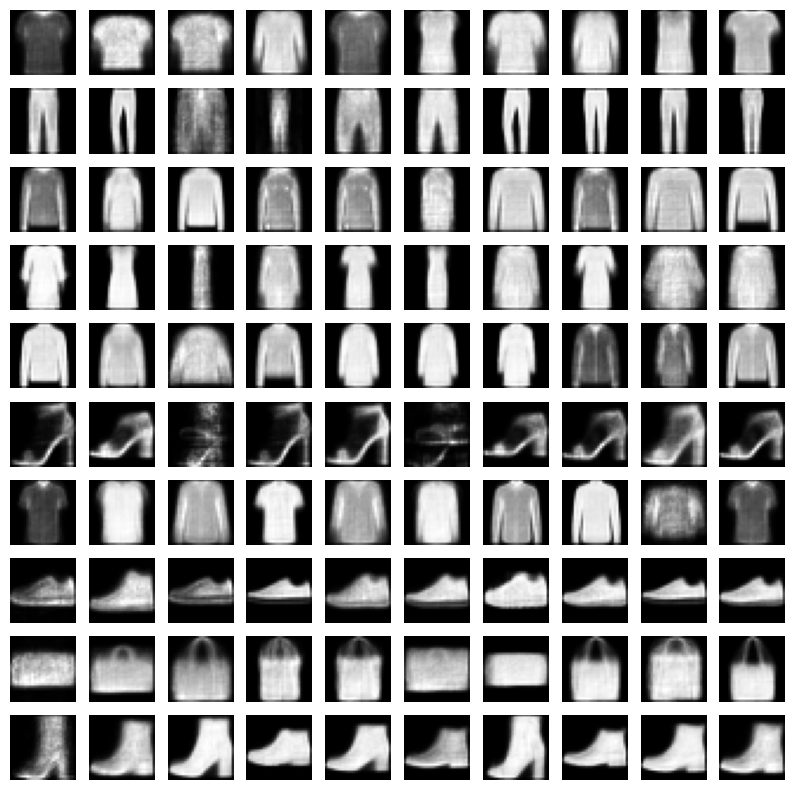

In [45]:
print("Autoencoder:")
plot_conditional_samples(model_AE_cond)
print("Variational Autoencoder:")
plot_conditional_samples(model_VAE_cond)

Aqui fica ainda mais claro o comportamento já visto na questão anterior, as imagens geradas pelo VAE tem qualidade melhor. No caso, como se tem acesso à classe esperada, dá para ter uma noção melhor de alguns objetos gerados pelo autoencoder, que parecem mais "borrões", além de perceber que o VAE realmente consegue ser mais diverso e gerar objetos diferentes dentro da mesma classe.